## ZOIDBERG2.0 – Pneumonia Detection
Ce projet vise à détecter la pneumonie à partir d'images de rayons X en utilisant différentes méthodes de machine learning . Nous explorerons plusieurs approches et comparerons leurs performances à l’aide de diverses métriques

---

## Extraction des données ( Drive )

In [1]:
# Import des librairies
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

In [2]:
# importation des donnees depuis gogle drive 
# les données brutes ont été conserver sur le drive mais ont a aussi des fichier en local qui ne seront pas pousser 



### Visualisation des données 

  --- 
Distribution des données :
- Par classe 

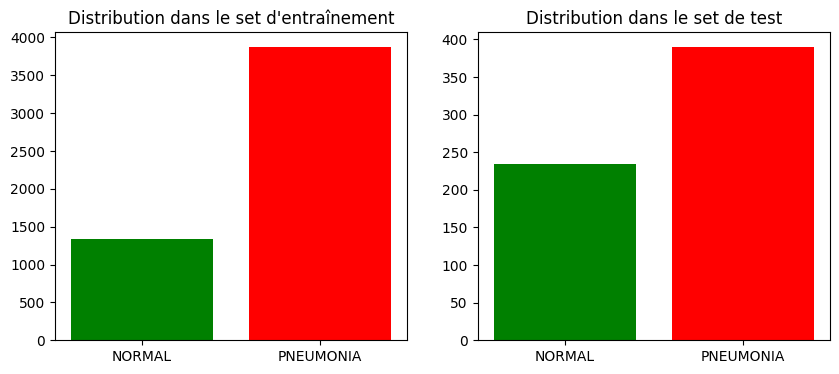

In [3]:
import os
import matplotlib.pyplot as plt

def count_images_in_dir(base_dir):
    classes = ['NORMAL', 'PNEUMONIA']
    counts = {}
    for cls in classes:
        cls_dir = os.path.join(base_dir, cls)
        counts[cls] = len([f for f in os.listdir(cls_dir) if f.endswith('.jpeg')])
    return counts

train_dir = "../data/raw/chest_Xray/train"
test_dir = "../data/raw/chest_Xray/test"

train_counts = count_images_in_dir(train_dir)
test_counts = count_images_in_dir(test_dir)

# Affichage
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(train_counts.keys(), train_counts.values(), color=["green", "red"])
axes[0].set_title("Distribution dans le set d'entraînement")
axes[1].bar(test_counts.keys(), test_counts.values(), color=["green", "red"])
axes[1].set_title("Distribution dans le set de test")
plt.show()


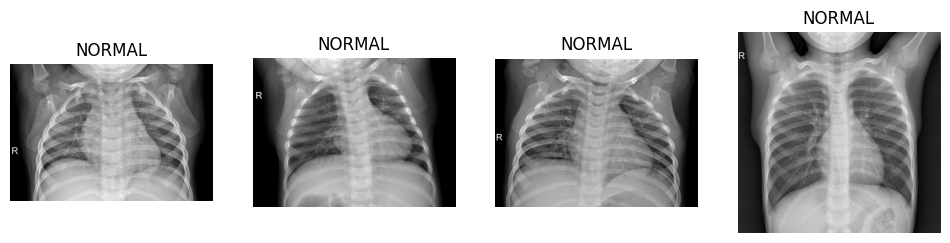

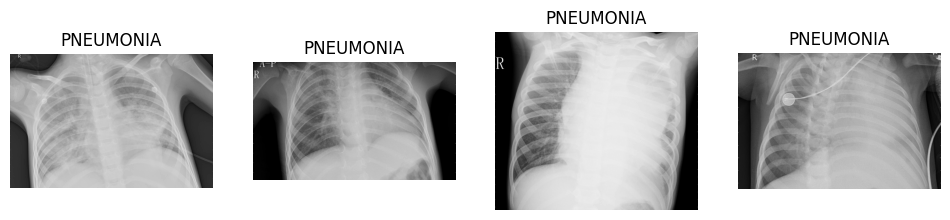

In [4]:
from PIL import Image
import random

def show_sample_images(path, category, n=4):
    image_files = [f for f in os.listdir(os.path.join(path, category)) if f.endswith('.jpeg')]
    sample_files = random.sample(image_files, n)

    plt.figure(figsize=(12, 4))
    for i, filename in enumerate(sample_files):
        img_path = os.path.join(path, category, filename)
        img = Image.open(img_path).convert('L')
        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(category)
        plt.axis('off')
    plt.show()

# Exemple d'affichage
show_sample_images(train_dir, "NORMAL")
show_sample_images(train_dir, "PNEUMONIA")


- Par dataset
  - Train , Validation , Set 

In [5]:
import os

def count_images_per_class(path, dataset_name=""):
    print(f"\n {dataset_name.upper()} set:")
    classes = ['NORMAL', 'PNEUMONIA']
    for cls in classes:
        cls_path = os.path.join(path, cls)
        n_images = len([f for f in os.listdir(cls_path) if f.endswith('.jpeg')])
        print(f"  - {cls}: {n_images} images")

# Définir les chemins avec chemin relatif depuis notebooks/
base_data_path = "../data/raw/chest_Xray"

# Appels
count_images_per_class(os.path.join(base_data_path, 'train'), 'train')
count_images_per_class(os.path.join(base_data_path, 'val'), 'validation')
count_images_per_class(os.path.join(base_data_path, 'test'), 'test')



 TRAIN set:
  - NORMAL: 1341 images
  - PNEUMONIA: 3875 images

 VALIDATION set:
  - NORMAL: 8 images
  - PNEUMONIA: 8 images

 TEST set:
  - NORMAL: 234 images
  - PNEUMONIA: 390 images


---
Observation : 
On observe qui il y a un grand déséquilibre dans la distribution des dataset avec un dataset de validation beacoup trop petits 

On va faire une redistribution des données en faisant une repartition 80/20 entre le training set et le validation set

---

In [6]:
# rebuild du dataset de train et de test
from sklearn.model_selection import train_test_split

# Fonctions pour charger les chemins et labels
def get_image_paths_and_labels(base_dir):
    classes = ['NORMAL', 'PNEUMONIA']
    image_paths = []
    labels = []
    for label, cls in enumerate(classes):
        cls_dir = os.path.join(base_dir, cls)
        for img_file in os.listdir(cls_dir):
            if img_file.endswith('.jpeg'):
                image_paths.append(os.path.join(cls_dir, img_file))
                labels.append(label)
    return image_paths, labels

# Charger les chemins d’images et labels depuis train/
train_paths, train_labels = get_image_paths_and_labels(os.path.join(base_data_path, 'train'))

#ajouter les quelques  element de vals
classes = ['NORMAL', 'PNEUMONIA']
for label, cls in enumerate(classes):
    cls_dir = os.path.join(base_data_path, 'val') 
    for img_file in os.listdir(cls_dir):
        if img_file.endswith('.jpeg'):
            train_paths.append(os.path.join(cls_dir, img_file))
            train_labels.append(label)

#Ici on va rebuild les datasets de train et de val
# Split 80% train / 20% val
X_train, X_val, y_train, y_val = train_test_split(
    train_paths, train_labels, test_size=0.2, stratify=train_labels, random_state=42
)

print(f"Train: {len(X_train)} images")
print(f"Validation: {len(X_val)} images")


Train: 4172 images
Validation: 1044 images


OK les dataset ont été équilibré

Sauvegarde temporaire 

In [7]:
def preprocess_images_cv2(image_paths, size=(64, 64)):
    data = []
    for path in image_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, size)
        data.append(img.flatten())
    return np.array(data)

In [8]:
# Prétraitement
X_train_np = preprocess_images_cv2(X_train)
X_val_np = preprocess_images_cv2(X_val)
y_train_np = np.array(y_train)
y_val_np = np.array(y_val)

# 📁 Sauvegarde dans data/processed/
processed_dir = "../data/processed"
os.makedirs(processed_dir, exist_ok=True)

np.save(os.path.join(processed_dir, "X_train.npy"), X_train_np)
np.save(os.path.join(processed_dir, "y_train.npy"), y_train_np)
np.save(os.path.join(processed_dir, "X_val.npy"), X_val_np)
np.save(os.path.join(processed_dir, "y_val.npy"), y_val_np)

### Modèles supervisés

### SVM

In [9]:
import numpy as np

X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")
X_val = np.load("../data/processed/X_val.npy")
y_val = np.load("../data/processed/y_val.npy")


In [10]:
#entrainement du model 

from sklearn.svm import SVC

svm = SVC(kernel='linear', probability=True, random_state=42)
svm.fit(X_train, y_train)

SVC(kernel='linear', probability=True, random_state=42)

Classification report:
               precision    recall  f1-score   support

      Normal       0.95      0.91      0.93       268
   Pneumonia       0.97      0.98      0.98       776

    accuracy                           0.96      1044
   macro avg       0.96      0.95      0.95      1044
weighted avg       0.96      0.96      0.96      1044



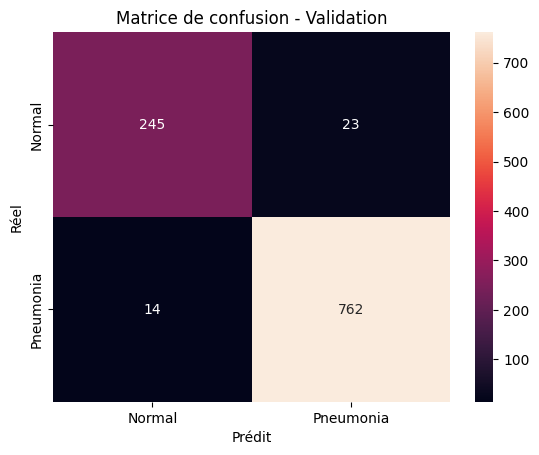

ROC-AUC Score : 0.9933


In [11]:
# Evaluation du model 
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = svm.predict(X_val)
y_proba = svm.predict_proba(X_val)[:, 1]

# Rapport
print("Classification report:\n", classification_report(y_val, y_pred, target_names=["Normal", "Pneumonia"]))

# Matrice de confusion
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt="d",
            xticklabels=["Normal", "Pneumonia"], yticklabels=["Normal", "Pneumonia"])
plt.title("Matrice de confusion - Validation")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# Score ROC-AUC
roc_auc = roc_auc_score(y_val, y_proba)
print(f"ROC-AUC Score : {roc_auc:.4f}")


### Variante PCA

In [12]:
from sklearn.decomposition import PCA

# On garde 95% de la variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)

print("Dimensions après PCA :")
print("Train:", X_train_pca.shape)
print("Val :", X_val_pca.shape)


Dimensions après PCA :
Train: (4172, 483)
Val : (1044, 483)


In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    verbose=2
)

grid.fit(X_train_pca, y_train)

print("Meilleurs paramètres :", grid.best_params_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.2s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.1s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.1s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.1s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.1s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   2.9s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   2.8s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   2.8s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   2.8s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   2.8s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=   1.1s
[CV] END ...................C=0.1, gamma=auto, k

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

best_model = grid.best_estimator_
y_pred = best_model.predict(X_val_pca)
y_proba = best_model.predict_proba(X_val_pca)[:, 1]

print("Classification Report:\n", classification_report(y_val, y_pred, target_names=["Normal", "Pneumonia"]))
print("ROC-AUC Score:", roc_auc_score(y_val, y_proba))


Classification Report:
               precision    recall  f1-score   support

      Normal       0.96      0.96      0.96       268
   Pneumonia       0.99      0.98      0.99       776

    accuracy                           0.98      1044
   macro avg       0.97      0.97      0.97      1044
weighted avg       0.98      0.98      0.98      1044

ROC-AUC Score: 0.9981102861978766


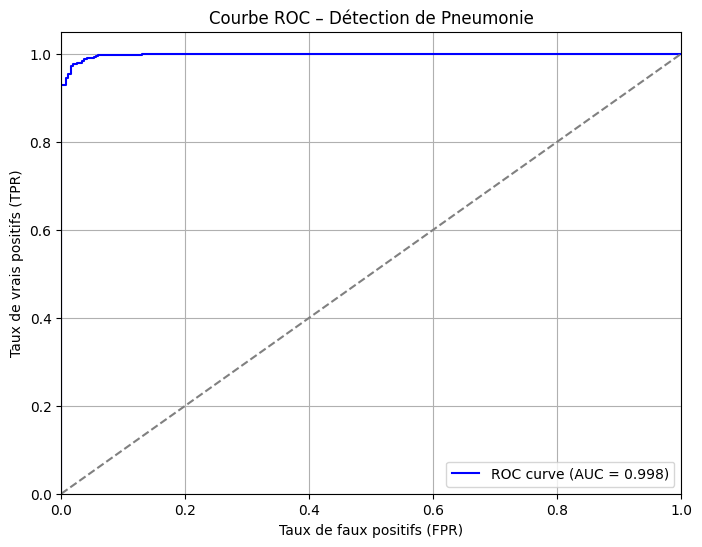

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calcul des points de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_val, y_proba)
roc_auc = auc(fpr, tpr)

# Tracé
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonale
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC – Détection de Pneumonie')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


Courbe ROC illustrant la capacité du modèle à discriminer les cas de pneumonie. L’AUC obtenue est de 0.998, indiquant une performance quasi parfaite.


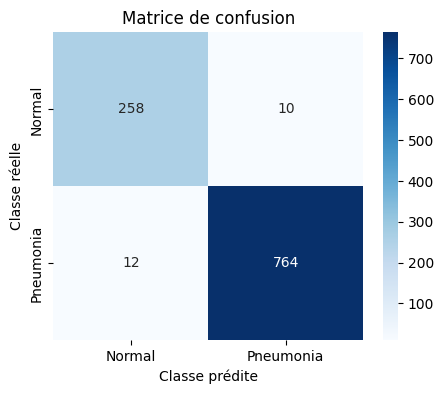

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal", "Pneumonia"],
            yticklabels=["Normal", "Pneumonia"])
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion")
plt.show()


In [16]:
def show_predictions_with_truth(model, image_paths, true_labels, img_size=(224, 224), n=4, class_names=["Normal", "Pneumonia"]):
    """
    Affiche n images avec la prédiction du modèle et la vérité terrain.
    """
    selected = random.sample(list(zip(image_paths, true_labels)), n)

    plt.figure(figsize=(15, 4))
    for i, (img_path, true_label) in enumerate(selected):
        # Chargement et prétraitement
        img = Image.open(img_path).convert('L').resize(img_size)
        img_arr = np.array(img) / 255.0
        flat_input = img_arr.flatten().reshape(1, -1)  # Si ton modèle prend des vecteurs

        # Prédiction
        proba = model.predict_proba(flat_input)[0]
        pred_label = np.argmax(proba)
        confidence = proba[pred_label]

        # Affichage
        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Vérité : {class_names[true_label]}\nPrédit : {class_names[pred_label]} ({confidence*100:.1f}%)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


In [20]:
# Supposons que tu as une liste `X_val_paths` avec les chemins des images utilisées pour X_val_pca
# Et `y_val` correspond à leurs étiquettes (0 ou 1)
show_predictions_with_truth(best_model,train_dir, y_val, img_size=(64,64))


IsADirectoryError: [Errno 21] Is a directory: '/'

<Figure size 1500x400 with 0 Axes>